In [1]:
import numpy as nu
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_csv("tripadvisor_hotel_reviews.csv")

In [3]:
data.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [4]:
data['Rating'].value_counts()

Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64

In [5]:
data1=data[data['Rating']>3]
data2=data[data['Rating']<=3]

In [6]:
l=[]
for i in data['Review']:
    l.append(len(i))

In [7]:
data['length']=l

In [8]:
data.head()

,Review,Rating,length
0,nice hotel expensive parking got good deal sta...,4,593
1,ok nothing special charge diamond member hilto...,2,1689
2,nice rooms not 4* experience hotel monaco seat...,3,1427
3,"unique, great stay, wonderful time hotel monac...",5,600
4,"great stay great stay, went seahawk game aweso...",5,1281


In [9]:
m=[]
for i in data['Review']:
    s=i.split(' ')
    m.append(len(s))


In [10]:
data['word_length']=m

In [11]:
data.head()

,Review,Rating,length,word_length
0,nice hotel expensive parking got good deal sta...,4,593,89
1,ok nothing special charge diamond member hilto...,2,1689,252
2,nice rooms not 4* experience hotel monaco seat...,3,1427,219
3,"unique, great stay, wonderful time hotel monac...",5,600,91
4,"great stay great stay, went seahawk game aweso...",5,1281,193


In [12]:
data['mean_sen_length']=(data['length'].sum())/len(data)

In [13]:
data['mean_word_length']=data['length']/data['word_length']

In [14]:
data.head()

,Review,Rating,length,word_length,mean_sen_length,mean_word_length
0,nice hotel expensive parking got good deal sta...,4,593,89,724.896833,6.662921
1,ok nothing special charge diamond member hilto...,2,1689,252,724.896833,6.702381
2,nice rooms not 4* experience hotel monaco seat...,3,1427,219,724.896833,6.515982
3,"unique, great stay, wonderful time hotel monac...",5,600,91,724.896833,6.593407
4,"great stay great stay, went seahawk game aweso...",5,1281,193,724.896833,6.637306


<Axes: >

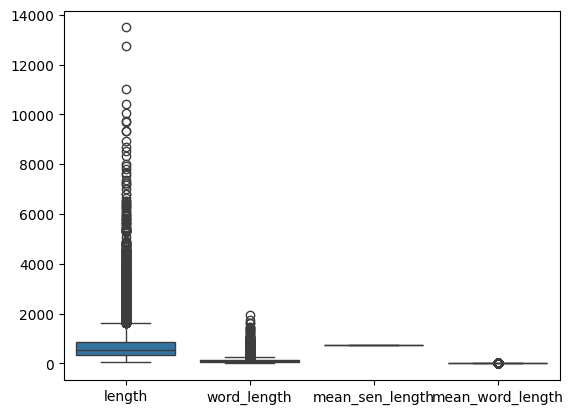

In [24]:
sns.boxplot(data.iloc[:,2:])

In [25]:
m=[]
for i in data['Review']:
    m.append(i.lower())

In [31]:
s=[]
for i in m:
    for j in i.split():
        s.append(j)
        
       
    

In [33]:
mostCommon = Counter(s).most_common(10)
mostCommon

[('hotel', 42079),
 ('not', 30750),
 ('room', 30532),
 ('great', 18732),
 ("n't", 18436),
 ('staff', 14950),
 ('good', 14791),
 ('did', 13433),
 ('just', 12458),
 ('stay', 11376)]

In [34]:
x=[]
y=[]
for i,j in mostCommon:
    x.append(i)
    y.append(j)

In [35]:
x

['hotel',
 'not',
 'room',
 'great',
 "n't",
 'staff',
 'good',
 'did',
 'just',
 'stay']

In [36]:
y

[42079, 30750, 30532, 18732, 18436, 14950, 14791, 13433, 12458, 11376]

<BarContainer object of 10 artists>

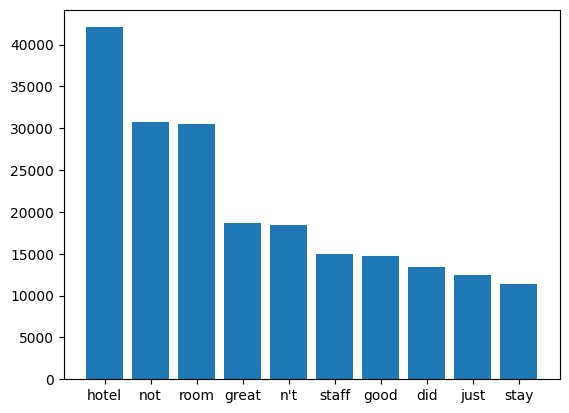

In [37]:
plt.bar(x,y)

In [40]:

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(2,2))
bigrams = cv.fit_transform(data['Review'])

In [51]:
count_values = bigrams[:1000].toarray().sum(axis=0)

In [52]:
ngram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv.vocabulary_.items()], reverse = True))
ngram_freq.columns = ["frequency", "ngram"]

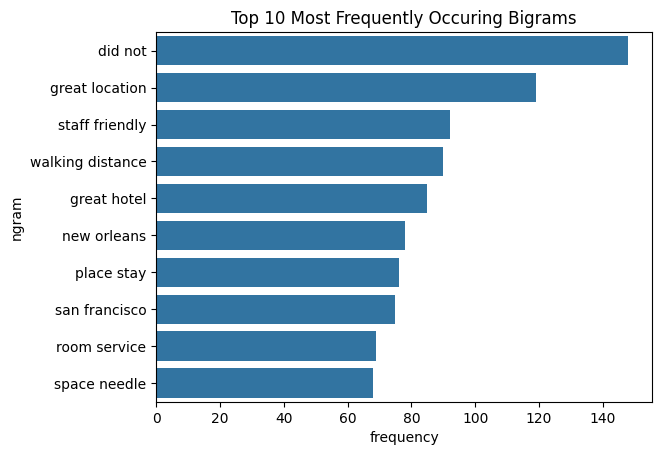

In [53]:
sns.barplot(x=ngram_freq['frequency'][:10], y=ngram_freq['ngram'][:10])
plt.title('Top 10 Most Frequently Occuring Bigrams')
plt.show()

In [56]:
cv1 = CountVectorizer(ngram_range=(3,3))
trigrams = cv1.fit_transform(data['Review'])
count_values = trigrams[:100].toarray().sum(axis=0)
ngram_freq = pd.DataFrame(sorted([(count_values[i], k) for k, i in cv1.vocabulary_.items()], reverse = True))
ngram_freq.columns = ["frequency", "ngram"]

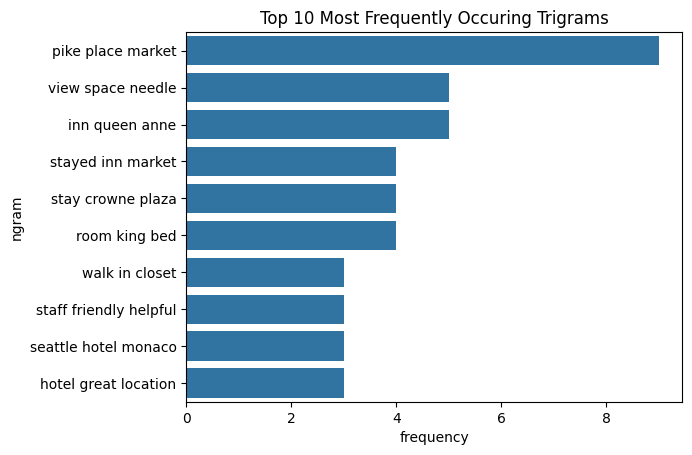

In [57]:
sns.barplot(x=ngram_freq['frequency'][:10], y=ngram_freq['ngram'][:10])
plt.title('Top 10 Most Frequently Occuring Trigrams')
plt.show()